In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!pip install tensorflow pillow matplotlib

In [5]:
from google.colab import files
files.upload()

Saving diabetic-retinopathy-detection.zip to diabetic-retinopathy-detection.zip


In [6]:
import zipfile

zip_ref = zipfile.ZipFile("diabetic-retinopathy-detection.zip","r")
zip_ref.extractall("/content/")
zip_ref.close()

In [7]:
!pip install tensorflow pillow matplotlib

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG = 224
BATCH = 16

train_dir = "/content/train"   # adjust path

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG,IMG),
    batch_size=BATCH,
    subset="training"
)

val = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG,IMG),
    batch_size=BATCH,
    subset="validation"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/train'

In [9]:
import zipfile

zip_ref = zipfile.ZipFile("diabetic-retinopathy-detection.zip", "r")
zip_ref.extractall("/content/")
zip_ref.close()

In [10]:
import os

print(os.listdir("/content"))

['.config', 'data', 'diabetic-retinopathy-detection.zip', 'sample_data']


In [11]:
import os
print(os.listdir("/content/data"))

['test', 'train']


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG = 224
BATCH = 16

train_dir = "/content/data/train"   # ✅ correct path

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG, IMG),
    batch_size=BATCH,
    subset="training"
)

val = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG, IMG),
    batch_size=BATCH,
    subset="validation"
)

Found 2585 images belonging to 5 classes.
Found 644 images belonging to 5 classes.


In [13]:
print(train.class_indices)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base = ResNet50(weights="imagenet", include_top=False)

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)

# VERY IMPORTANT LINE ↓
output = Dense(5, activation="softmax")(x)   # connect layer to x

model = Model(inputs=base.input, outputs=output)

for layer in base.layers:
    layer.trainable = False

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
history = model.fit(train, validation_data=val, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 73s 367ms/step - accuracy: 0.5072 - loss: 1.2502 - val_accuracy: 0.5699 - val_loss: 1.0476
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 48s 296ms/step - accuracy: 0.6291 - loss: 1.0003 - val_accuracy: 0.6165 - val_loss: 1.0679
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 286ms/step - accuracy: 0.6523 - loss: 0.9658 - val_accuracy: 0.6025 - val_loss: 1.0988
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 283ms/step - accuracy: 0.6638 - loss: 0.9513 - val_accuracy: 0.6258 - val_loss: 1.0134
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 47s 288ms/step - accuracy: 0.6372 - loss: 1.0148 - val_accuracy: 0.5932 - val_loss: 1.1048
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 47s 290ms/step - accuracy: 0.6364 - loss: 0.9997 - val_accuracy: 0.6351 - val_loss: 0.9956
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 285ms/step - accuracy: 0.6600 - loss: 0.9560 - val_accuracy: 0.6242 - val_loss: 0.9950
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 285ms/step - accuracy: 0.6526 - loss: 0

In [20]:
model.save("dr_model.h5")
print("Model saved")

Model saved


In [21]:
from google.colab import files
files.download("dr_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from google.colab import files
files.upload()

Saving test_image.jpg to test_image.jpg


{'test_image.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\n\x07\x07\t\x07\x06\n\t\x08\t\x0b\x0b\n\x0c\x0f\x19\x10\x0f\x0e\x0e\x0f\x1e\x16\x17\x12\x19$ &%# #"(-90(*6+"#2D26;=@@@&0FKE>J9?@=\xff\xdb\x00C\x01\x0b\x0b\x0b\x0f\r\x0f\x1d\x10\x10\x1d=)#)==================================================\xff\xc0\x00\x11\x08\x00\xdc\x01J\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\

In [32]:
from PIL import Image
import numpy as np

classes = ['Mild','Moderate','No_DR','Proliferate_DR','Severe']

img = Image.open("test_image.jpg").resize((224,224))

img = np.array(img)/255.0
img = np.expand_dims(img, axis=0)

pred = model.predict(img)

print("Prediction:", classes[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: No_DR


In [33]:
print("Training Accuracy:", history.history['accuracy'][-1]*100)
print("Validation Accuracy:", history.history['val_accuracy'][-1]*100)

Training Accuracy: 66.30560755729675
Validation Accuracy: 60.71428656578064


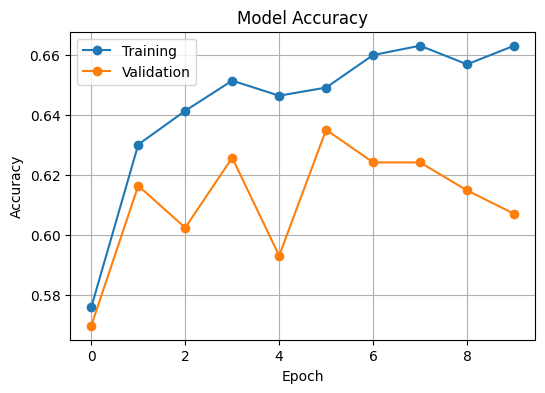

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.grid(True)
plt.show()

In [35]:
test_datagen = ImageDataGenerator(rescale=1./255)

test = test_datagen.flow_from_directory(
    "/content/data/test",
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 361 images belonging to 5 classes.


In [36]:
loss, acc = model.evaluate(test)
print("Test Accuracy:", acc*100)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4218 - loss: 1.4197
Test Accuracy: 58.725762367248535


23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step


<Axes: >

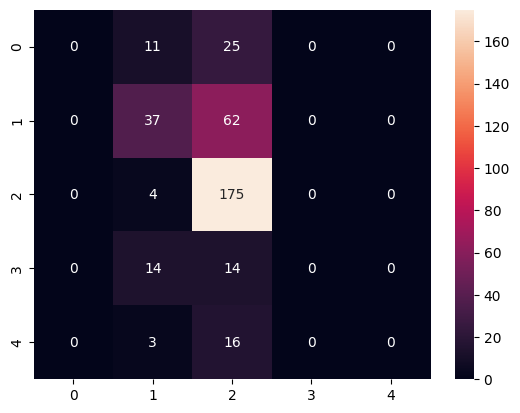

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred = model.predict(test)
y_pred = pred.argmax(axis=1)

cm = confusion_matrix(test.classes, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step


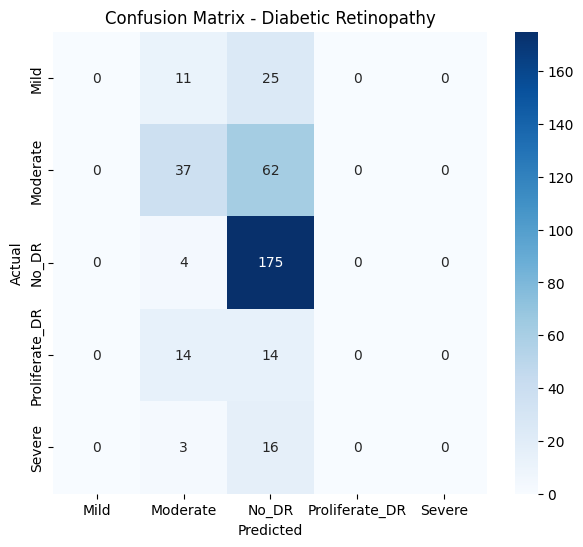

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predict on test data
pred = model.predict(test)
y_pred = np.argmax(pred, axis=1)

# Confusion matrix
cm = confusion_matrix(test.classes, y_pred)

# Plot
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test.class_indices.keys(),
            yticklabels=test.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Diabetic Retinopathy")
plt.show()

In [31]:
loss, acc = model.evaluate(test)
print("Test Accuracy:", acc*100)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4218 - loss: 1.4197
Test Accuracy: 58.725762367248535


In [37]:
from sklearn.metrics import classification_report

print(classification_report(test.classes, y_pred,
      target_names=test.class_indices.keys()))

                precision    recall  f1-score   support

          Mild       0.00      0.00      0.00        36
      Moderate       0.54      0.37      0.44        99
         No_DR       0.60      0.98      0.74       179
Proliferate_DR       0.00      0.00      0.00        28
        Severe       0.00      0.00      0.00        19

      accuracy                           0.59       361
     macro avg       0.23      0.27      0.24       361
  weighted avg       0.44      0.59      0.49       361



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
model.save("dr_model.keras")

In [39]:
model.save("dr_model.h5")

In [40]:
for layer in model.layers[-30:]:
    layer.trainable = True

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train, validation_data=val, epochs=5)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 82s 350ms/step - accuracy: 0.6993 - loss: 0.8862 - val_accuracy: 0.6149 - val_loss: 0.9880
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - accuracy: 0.7009 - loss: 0.8354 - val_accuracy: 0.6879 - val_loss: 0.8630
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 45s 280ms/step - accuracy: 0.6979 - loss: 0.8627 - val_accuracy: 0.6925 - val_loss: 0.8487
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 282ms/step - accuracy: 0.6851 - loss: 0.8897 - val_accuracy: 0.6786 - val_loss: 0.8722
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 45s 277ms/step - accuracy: 0.6837 - loss: 0.8624 - val_accuracy: 0.7019 - val_loss: 0.8271


In [43]:
model.save("dr_model.keras")

In [44]:
from google.colab import files
files.download("dr_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
loss, acc = model.evaluate(test)
print("Test Accuracy:", acc*100)

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.5865 - loss: 1.0366
Test Accuracy: 69.8060929775238


In [46]:
pred = model.predict(test)
y_pred = pred.argmax(axis=1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test.classes, y_pred)

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step


In [47]:
from sklearn.metrics import classification_report
print(classification_report(test.classes, y_pred,
                            target_names=test.class_indices.keys()))

                precision    recall  f1-score   support

          Mild       0.00      0.00      0.00        36
      Moderate       0.50      0.79      0.61        99
         No_DR       0.85      0.97      0.91       179
Proliferate_DR       0.00      0.00      0.00        28
        Severe       0.00      0.00      0.00        19

      accuracy                           0.70       361
     macro avg       0.27      0.35      0.30       361
  weighted avg       0.56      0.70      0.62       361



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
